# k-Nearest Neighbors

In [1]:
# Libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

In [2]:
# Dataset Class from Q1
class StudentDataset:
    """
        A class that generates and visualizes a student demographic.
        Parameters:
            num_students (int): The number of students to generate.
            seed (int): The random seed for reproducibility.
    """

    def __init__(self, num_students: int, seed: int, username: str):
        """
            Sets up the initial variables like num_students, seed and calls the data generation methods.
        """
        self.num_students = num_students
        self.seed = seed
        self.username = username
        np.random.seed(seed) # Set the deterministic seed generated based on username in the previous cell
        self.data = self.assemble_dataframe()

    def assemble_dataframe(self):
        """
            Assembles the full dataset from gender, major, program, and GPA.
            Returns:
                pd.DataFrame: A DataFrame containing the student demographic data.
        """
        
        gender = self.generate_gender()
        major = self.generate_major()
        program = self.generate_program(major)
        gpa = self.generate_gpa(major)

        data = {
            'Gender': gender,
            'Major': major,
            'Program': program,
            'GPA': gpa
        }

        return pd.DataFrame(data)

    def generate_gender(self) -> list[str]:
        """
            Generates a list of genders among {Male, Female, Other} with probabilities {0.65, 0.33, 0.02} respectively
            Returns:
                list[str]: A list of genders for the students.
        """

        genders = ["Male", "Female", "Other"]
        probs = [0.65, 0.33, 0.02]
        return np.random.choice(genders, size=self.num_students, p=probs).tolist()

    def generate_major(self) -> list[str]:
        """
            Generates a list of majors among {B.Tech, MS, PhD} with probabilities {0.7, 0.2, 0.1} respectively
            Returns:
                list[str]: A list of majors for the students.
        """

        majors = ["B.Tech", "MS", "PhD"]
        probs = [0.7, 0.2, 0.1]
        return np.random.choice(majors, size=self.num_students, p=probs).tolist()

    def generate_program(self, majors: list[str]) -> list[str]:
        """
            Generates a list of programs among {CSE, ECE, CHD, CND} conditioned on the major.
            Parameters:
                majors (list[str]): A list of majors for the students.
            Returns:
                list[str]: A list of programs for the students.
        """

        programs = []
        for major in majors:
            if major == "B.Tech":
                programs.append(np.random.choice(["CSE", "ECE", "CHD", "CND"], p=[0.4, 0.4, 0.1, 0.1]))
            elif major == "MS":
                programs.append(np.random.choice(["CSE", "ECE", "CHD", "CND"], p=[0.3, 0.3, 0.2, 0.2]))
            else:
                programs.append(np.random.choice(["CSE", "ECE", "CHD", "CND"], p=[0.25, 0.25, 0.25, 0.25]))

        return programs

    def generate_gpa(self, majors: list[str]) -> list[float]:
        """
            Generates a list of GPAs conditioned on the major. Values are clipped to [4.0, 10.0]
            Parameters:
                majors (list[str]): A list of majors for the students.
            Returns:
                list[float]: A list of GPAs for the students.
        """

        gpa = []
        for major in majors:
            if major == "B.Tech":
                gpa.append(np.clip(np.random.normal(7.0, 1.0), 4.0, 10.0))
            elif major == "MS":
                gpa.append(np.clip(np.random.normal(8.0, 0.49), 4.0, 10.0))
            else:
                gpa.append(np.clip(np.random.normal(8.3, 0.25), 4.0, 10.0))

        return gpa
        
    def get_full_dataframe(self) -> pd.DataFrame:
        """
            Returns the full DataFrame containing the student demographic data.
            Returns:
                pd.DataFrame: The DataFrame with student demographics.
        """
        return self.data

In [3]:
class PerFeatureTransformer:
    def __init__(self):
        """
            Initializes memory for per-feature transformers.
        """
        self.transformers = {}
        self.params = {}

    def fit(self, df: pd.DataFrame, params: dict[str, str])-> None:
        """
            Fits transformers for each feature based on the given type.
            Parameters:
                df: The dataframe containing features to be transformed.
                params: A dictionary mapping feature name to
                transformation type,
                e.g., {"GPA": "standard", "major": "ordinal", "program":
                "onehot"}.
        """
        self.params = params
        for feature, method in params.items():
            if method == "standard":
                scaler = StandardScaler()
                scaler.fit(df[[feature]]) # df[feature] is of shape (n,) and df[[feature]] is of shape (n, 1) which is expected by the scikit-learn transformer function
                self.transformers[feature] = scaler
                # print("Standard Scaler: ", scaler)
                # print("Mean: ", scaler.mean_)
                # print("Standard Deviation: ", scaler.var_)

            elif method == "ordinal":
                encoder = OrdinalEncoder()
                encoder.fit(df[[feature]])
                self.transformers[feature] = encoder
                # print("Ordinal Encoder: ", encoder)
                # print("Categories: ", encoder.categories_)

            elif method == "onehot":
                encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
                encoder.fit(df[[feature]])
                self.transformers[feature] = encoder
                # print("One-Hot Encoder: ", encoder)
                # print("Categories: ", encoder.categories_)

            else:
                raise ValueError(f"Error in transforming using {method} for feature {feature}")
            
    def transform(self, df: pd.DataFrame)-> np.ndarray:
        """
            Applies the fitted transformers to the corresponding features and returns a NumPy array.
            Parameters:
                df: The dataframe containing features to be transformed.
            Returns:
                A NumPy array containing the transformed features.
        """
        transformed_list = []
        for feature, method in self.params.items():
            transformer = self.transformers[feature]
            transformed = transformer.transform(df[[feature]])
            transformed_list.append(transformed)
        return np.hstack(transformed_list)

    def fit_transform(self, df: pd.DataFrame, params: dict[str, str])-> np.ndarray:
        """
            Fits and transforms all features in one step using the given transformation parameters.
            Parameters:
                df: The dataframe containing features to be transformed.
                params: A dictionary mapping feature name to transformation type.
            Returns:
                A NumPy array containing the transformed features.
        """
        self.fit(df, params)
        return self.transform(df)

In [4]:
class KNNGenderPredictor:

    def _add_username(self) -> None:
        plt.text(0.95, 0.4, self.username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

    def __init__(self, student_df: pd.DataFrame, username: str, seed: int):
        """
            Initializes the KNNGenderPredictor with the student DataFrame.
            Parameters:
                student_df (pd.DataFrame): The DataFrame containing student data.
                username (str): The username for the plots.
                seed (int): The random seed for reproducibility.
        """
        self.df = student_df
        self.username = username
        self.seed = seed
        self.transformer = PerFeatureTransformer()
        self.X_train = self.X_val = self.X_test = None
        self.y_train = self.y_val = self.y_test = None

    def train_val_test_split(self, test_size: float = 0.2, val_size: float = 0.2):
        """
            Splits dataset into train, validation, and test sets.
            Parameters:
                test_size (float): The proportion of the dataset to include in the test split.
                val_size (float): The proportion of the training dataset to include in the validation split.
            Returns:
                Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]: The train, validation, and test DataFrames.
        """
        train_df, test_df = train_test_split(self.df, test_size=test_size, random_state=self.seed, stratify=self.df["Gender"])
        train_df, val_df = train_test_split(train_df, test_size=val_size/(1-test_size), random_state=self.seed, stratify=train_df["Gender"])
        # print("Training data and size")
        # print(train_df.head())
        # print(train_df.shape)
        # print("Validation data and size")
        # print(val_df.head())
        # print(val_df.shape)
        # print("Test data and size")
        # print(test_df.head())
        # print(test_df.shape)
        return train_df, val_df, test_df

    def get_feature_matrix_and_labels(self, df: pd.DataFrame, features: dict[str, str]):
        """
            Extract features and labels with transformations.
            Parameters:
                df (pd.DataFrame): The DataFrame from which to extract features and labels.
                features (dict[str, str]): A dictionary mapping feature names to their transformation types.
            Returns:
                Tuple[np.ndarray, np.ndarray]: The feature matrix X and the label array y.
        """
        X = self.transformer.fit_transform(df, features)
        y = df["Gender"].values
        return X, y

    def prepare_data(self, train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, params: dict[str, str]) -> None:
        """
            Prepares the data by extracting features and labels for train, validation, and test sets.
            Parameters:
                train_df (pd.DataFrame): The training DataFrame.
                val_df (pd.DataFrame): The validation DataFrame.
                test_df (pd.DataFrame): The test DataFrame.
                params (dict[str, str]): The parameters for feature extraction.
        """
        self.X_train, self.y_train = self.get_feature_matrix_and_labels(train_df, params)
        self.X_val, self.y_val = self.get_feature_matrix_and_labels(val_df, params)
        self.X_test, self.y_test = self.get_feature_matrix_and_labels(test_df, params)
        
        # print("Training features shape:", self.X_train.shape)
        # print("Validation features shape:", self.X_val.shape)
        # print("Test features shape:", self.X_test.shape)
        # print("Training labels shape:", self.y_train.shape)
        # print("Validation labels shape:", self.y_val.shape)
        # print("Test labels shape:", self.y_test.shape)

    def get_knn_accuracy_vs_k(self, k_values: list[int], distance: str = "euclidean") -> list[float]:
        """
            Get KNN accuracy for different values of k.
            Parameters:
                k_values (list[int]): The list of k values to evaluate.
                distance (str): The distance metric to use.
            Returns:
                list[float]: A list of accuracy scores for each k value.
        """
        accuracies = []
        for k in k_values:
            knn = KNeighborsClassifier(n_neighbors=k, metric=distance)
            knn.fit(self.X_train, self.y_train) # Lazy Learner strategy, just saves data here
            y_pred = knn.predict(self.X_val) # Distances are actually computed heres
            accuracies.append(accuracy_score(self.y_val, y_pred))
        return accuracies

    def plot_knn_accuracy_vs_k(self, k_values: list[int], accuracies: list[float], distance: str = "euclidean") -> None:
        """
            Plot KNN accuracy vs k. Prints the max accuracy and k as well
            Parameters:
                k_values (list[int]): The list of k values.
                accuracies (list[float]): The list of accuracy scores.
                distance (str): The distance metric used.
        """
        plt.plot(k_values, accuracies, marker="o")
        plt.title(f"KNN Accuracy vs K (Distance: {distance})")
        self._add_username()
        plt.xlabel("k")
        plt.xticks(k_values)
        plt.ylabel("Validation Accuracy")
        plt.grid(True)
        plt.show()

        max_accuracy = max(accuracies)
        best_k = k_values[accuracies.index(max_accuracy)]
        print(f"Max Accuracy: {max_accuracy:.4f} at k={best_k}")

    def get_knn_f1_heatmap(self, X_train: pd.DataFrame, y_train: pd.Series, X_val: pd.DataFrame, y_val: pd.Series, k_values: list[int], distances: list[str]) -> pd.DataFrame:
        """
            Get KNN F1 scores for different values of k and distance metrics.
            Parameters:
                X_train (pd.DataFrame): The training feature matrix.
                y_train (pd.Series): The training label array.
                X_val (pd.DataFrame): The validation feature matrix.
                y_val (pd.Series): The validation label array.
                k_values (list[int]): The list of k values to evaluate.
                distances (list[str]): The list of distance metrics to evaluate.
            Returns:
                pd.DataFrame: A DataFrame containing the F1 scores.
        """
        scores = {}
        for dist in distances:
            row = []
            for k in k_values:
                knn = KNeighborsClassifier(n_neighbors=k, metric=dist)
                knn.fit(X_train, y_train)
                y_pred = knn.predict(X_val)
                row.append(f1_score(y_val, y_pred, average="weighted"))
            scores[dist] = row
        return pd.DataFrame(scores, index=k_values)

    def plot_knn_f1_heatmap(self, f1_scores_df: pd.DataFrame) -> None:
        """
            Plot the KNN F1 Score Heatmap.
            Parameters:
                f1_scores_df (pd.DataFrame): The DataFrame containing F1 scores.
        """
        plt.figure(figsize=(8,6))
        sns.heatmap(f1_scores_df, annot=True, fmt=".4f")
        self._add_username()
        plt.title("KNN F1 Score Heatmap")
        plt.xlabel("k")
        plt.ylabel("Distance Metric")
        plt.show()

    def get_knn_f1_single_feature_table(self, k_values: list[int], features: list[str], distances: list[str] = ["euclidean", "manhattan", "cosine"]) -> list[dict]:
        """
            Get KNN F1 scores for a single feature across different k values and distance metrics.
            Parameters:
                k_values (list[int]): The list of k values to evaluate.
                features (list[str]): The list of features to evaluate.
                distances (list[str]): Distance metrics to evaluate.
            Returns:
                list[dict] : A list of dictionaries containing F1 scores for each feature.
        """
        # The mapping here depends on the encoding. SO need to be careful about it
        results = []
        for dist in distances:
            for feature in features:
                for k in k_values:

                    if feature == "Program":
                        x_train_feature = self.X_train[:, 4:]
                        x_test_feature = self.X_test[:, 4:]

                    elif feature == "Major":
                        x_train_feature = self.X_train[:, 1:4]
                        x_test_feature = self.X_test[:, 1:4]
                    else:
                        x_train_feature = self.X_train[:, [0]]
                        x_test_feature = self.X_test[:, [0]]

                    knn = KNeighborsClassifier(n_neighbors=k, metric=dist)
                    knn.fit(x_train_feature, self.y_train)
                    y_pred = knn.predict(x_test_feature)

                    results.append({'Distance': dist, 'Feature': feature, 'k': k, 'F1 Score': f1_score(self.y_test, y_pred, average="weighted")})

        return results

    def plot_knn_f1_single_feature_table(self, f1_scores_res) -> None:
        """
            Plot the KNN F1 Score Table for single features.
            Parameters:
                f1_scores_res (list[dict]): List of dictionaries containing F1 scores for each feature.
        """
        # Accumulate results for the same distance and plot a heatmap with features on the x-axis and k on the y-axis
        for dist in set(item['Distance'] for item in f1_scores_res):
            filtered_data = [item for item in f1_scores_res if item['Distance'] == dist]

            for feature in set(item['Feature'] for item in filtered_data):
                max_f1 = max(item['F1 Score'] for item in filtered_data if item['Feature'] == feature)
                best_k = [item['k'] for item in filtered_data if item['Feature'] == feature and item['F1 Score'] == max_f1]
                print(f"Highest F1 Score for {feature} (Distance: {dist}): {max_f1:.4f} at k={best_k}")

            heatmap_data = pd.DataFrame(filtered_data).pivot(index='k', columns='Feature', values='F1 Score')
            plt.figure(figsize=(8,6))
            sns.heatmap(heatmap_data, annot=True, fmt=".4f")
            self._add_username()
            plt.title(f"KNN F1 Score Heatmap (Distance: {dist})")
            plt.xlabel("Feature")
            plt.ylabel("k")
            plt.show()

In [5]:
# Misc Helper Functions
def print_separator():
    print("=" * 40)

Seed value :  2198587646
Student Dataset size:  (10000, 4)
   Gender   Major Program       GPA
0    Male  B.Tech     CND  6.914213
1    Male  B.Tech     ECE  7.372174
2    Male  B.Tech     CSE  6.302729
3  Female  B.Tech     CHD  6.044081
4    Male  B.Tech     CND  7.629295
 .....
      Gender   Major Program       GPA
9995  Female  B.Tech     CSE  5.620118
9996    Male  B.Tech     CSE  6.221395
9997    Male  B.Tech     ECE  5.481264
9998  Female  B.Tech     CSE  6.379722
9999  Female  B.Tech     ECE  6.377501
[[-1.43658126  1.          0.          0.          1.          0.
   0.          0.        ]
 [ 0.93154187  1.          0.          0.          1.          0.
   0.          0.        ]
 [ 0.95670076  1.          0.          0.          0.          0.
   1.          0.        ]
 [ 0.49620059  0.          1.          0.          0.          0.
   1.          0.        ]
 [ 1.17217691  1.          0.          0.          0.          0.
   0.          1.        ]]
Transformed featur

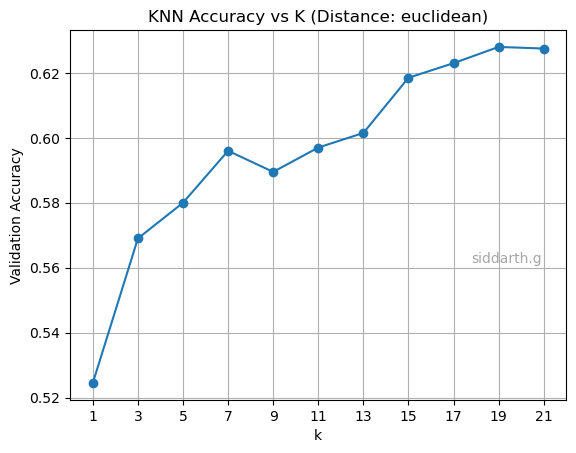

Max Accuracy: 0.6280 at k=19
k = 19 gives us the highest accuracy on the validation set with an accuracy of 62.8%


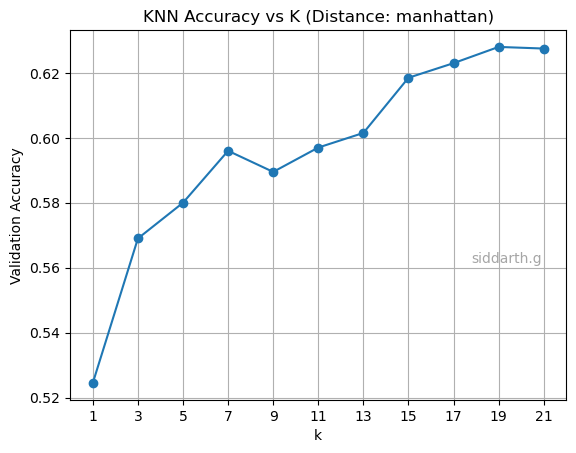

Max Accuracy: 0.6280 at k=19
k = 19 gives us the highest accuracy on the validation set even for Manhattan with an accuracy of 62.8%


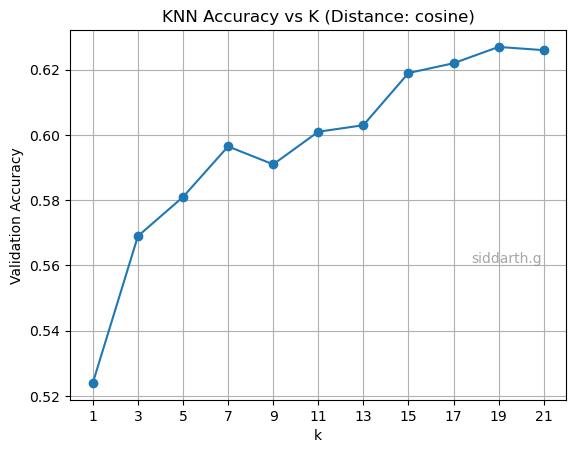

Max Accuracy: 0.6270 at k=19
k = 19 gives us the highest accuracy on the validation set with an accuracy of 62.7%
Printing F1 score data
    euclidean  manhattan    cosine
1    0.527110   0.527110  0.526534
3    0.553953   0.553953  0.553953
5    0.551848   0.551848  0.552598
7    0.555495   0.555495  0.556302
9    0.540070   0.540070  0.540684
11   0.541366   0.541366  0.545856
13   0.540341   0.540341  0.541335
15   0.550491   0.550491  0.551229
17   0.545414   0.545414  0.544222
19   0.546756   0.546756  0.545550
21   0.536516   0.536516  0.534983
Best F1 Score for euclidean: 0.5555 at k=7
Best F1 Score for manhattan: 0.5555 at k=7
Best F1 Score for cosine: 0.5563 at k=7


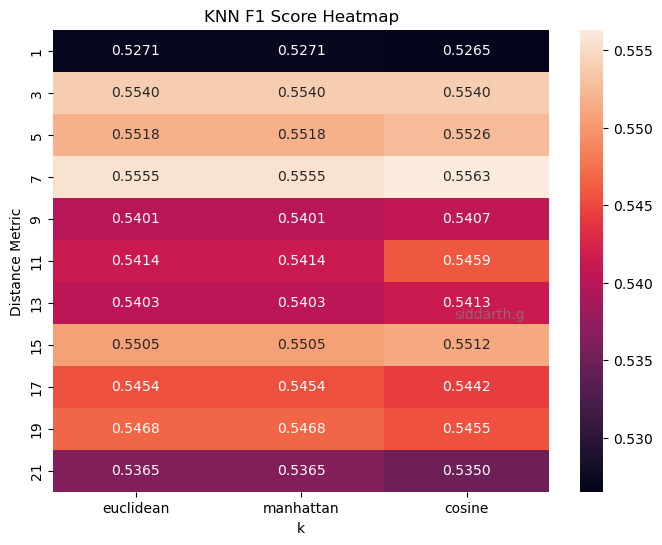

The distance metric cosine performs better. Although all the F1 scores are quite similar, we see a very slight advantage in using cosine similarity.
Highest F1 Score for Major (Distance: cosine): 0.5197 at k=[5, 7, 9, 11, 13, 15, 17, 19, 21]
Highest F1 Score for Program (Distance: cosine): 0.5540 at k=[13, 15]
Highest F1 Score for GPA (Distance: cosine): 0.5197 at k=[9, 11, 13, 17, 19, 21]


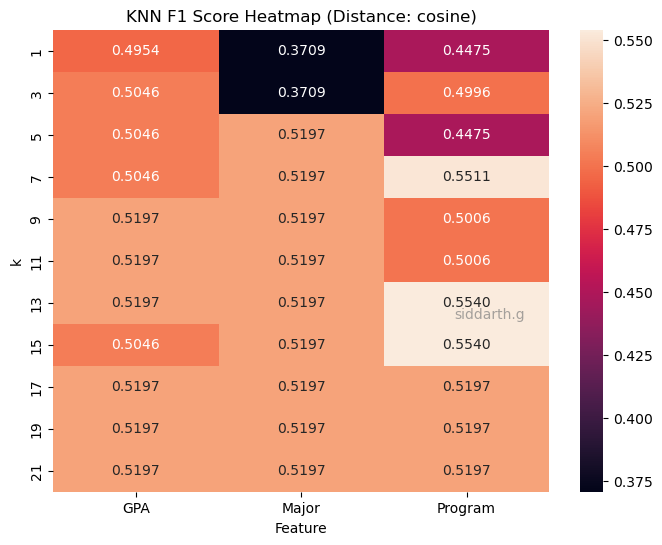

Highest F1 Score for Major (Distance: euclidean): 0.5388 at k=[13]
Highest F1 Score for Program (Distance: euclidean): 0.5344 at k=[3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
Highest F1 Score for GPA (Distance: euclidean): 0.5611 at k=[11]


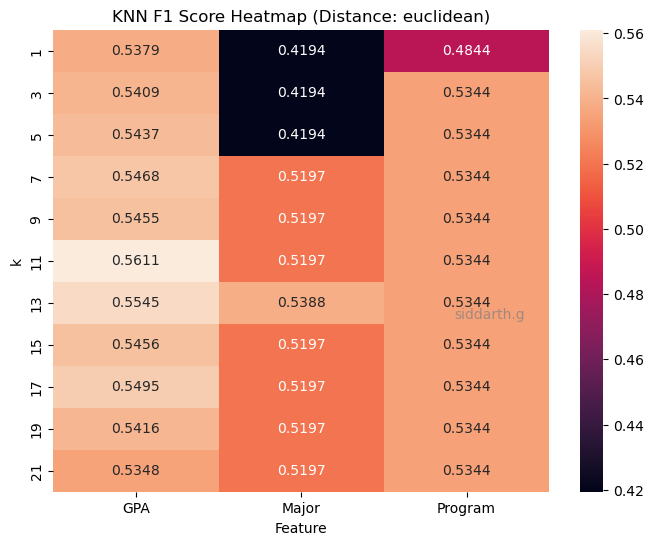

Highest F1 Score for Major (Distance: manhattan): 0.5388 at k=[13]
Highest F1 Score for Program (Distance: manhattan): 0.5344 at k=[3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
Highest F1 Score for GPA (Distance: manhattan): 0.5611 at k=[11]


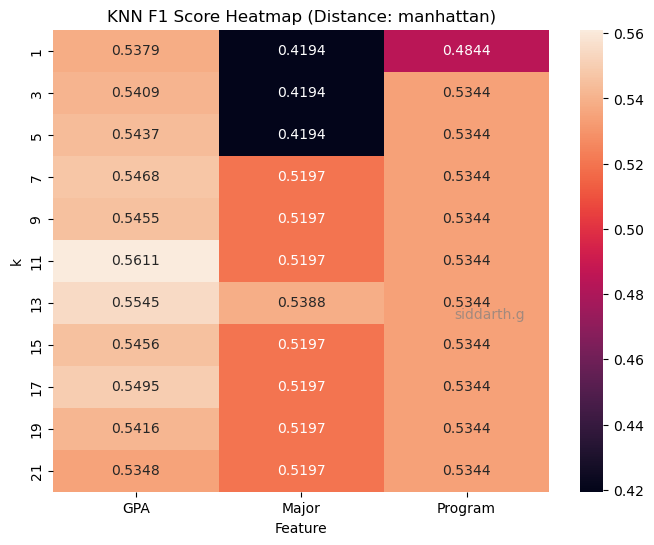

The feature GPA performs the best when using the Euclidean distance(score = 0.5611 at k = 11) or the Manhattan distance(score = 0.5611 at k = 11). In case of the Cosine distance, the feature Program performs the best(score = 0.5540 at k = 13, 15). The F1 scores are quite similar across all features. This shows that the data points are very uniformly interspersed and it is hard to tell them apart. This also makes sense intuitively as the GPA, Program and Major have no direct correlation with the Gender of the person


In [6]:
if __name__ == "__main__":

    # Generating a personalized random seed
    username = "siddarth.g"
    seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
    print("Seed value : ", seed)
    print_separator()

    dataset = StudentDataset(num_students=10000, seed=seed, username=username)
    df = dataset.get_full_dataframe()
    print("Student Dataset size: ", df.shape)
    print(df.head())
    print(" .....")
    print(df.tail())
    print_separator()

    transformer = PerFeatureTransformer()
    params = {"GPA": "standard", "Major": "onehot", "Program": "onehot"}
    X_transformed = transformer.fit_transform(df, params)
    print(X_transformed[5:10])
    print("Transformed feature matrix shape: ", X_transformed.shape, X_transformed.dtype)
    print("First Column is the CGPA, Second Column is the Ordinal encoding of the major, Third Column is the One-Hot encoding of the program.")
    print_separator()

    knn_predictor = KNNGenderPredictor(student_df=df, username=username, seed=seed)
    train, val, test = knn_predictor.train_val_test_split()
    # params={"GPA": "standard", "Major": "onehot", "Program": "onehot"}
    knn_predictor.prepare_data(train, val, test, params=params)

    # X_train, y_train = knn_predictor.get_feature_matrix_and_labels(train, params)
    # X_val, y_val = knn_predictor.get_feature_matrix_and_labels(val, params)
    # X_test, y_test = knn_predictor.get_feature_matrix_and_labels(test, params)

    k_vals = list(range(1, 22, 2)) # Odd values from 1 to 21
    accuracies = knn_predictor.get_knn_accuracy_vs_k(k_values=k_vals, distance="euclidean")
    knn_predictor.plot_knn_accuracy_vs_k(k_values=k_vals, accuracies=accuracies, distance="euclidean")
    print("k = 19 gives us the highest accuracy on the validation set with an accuracy of 62.8%")
    print_separator()

    accuracies = knn_predictor.get_knn_accuracy_vs_k(k_values=k_vals, distance="manhattan")
    knn_predictor.plot_knn_accuracy_vs_k(k_values=k_vals, accuracies=accuracies, distance="manhattan")
    print("k = 19 gives us the highest accuracy on the validation set even for Manhattan with an accuracy of 62.8%")
    print_separator()

    accuracies = knn_predictor.get_knn_accuracy_vs_k(k_values=k_vals, distance="cosine")
    knn_predictor.plot_knn_accuracy_vs_k(k_values=k_vals, accuracies=accuracies, distance="cosine")
    print("k = 19 gives us the highest accuracy on the validation set with an accuracy of 62.7%")
    print_separator()

    f1_df = knn_predictor.get_knn_f1_heatmap(knn_predictor.X_train, knn_predictor.y_train, knn_predictor.X_val, knn_predictor.y_val, k_values=k_vals, distances=["euclidean", "manhattan", "cosine"])
    print("Printing F1 score data")
    print(f1_df)
    print_separator()

    for dist in f1_df.columns:
        max_f1 = f1_df[dist].max()
        best_k = f1_df[dist].idxmax()
        print(f"Best F1 Score for {dist}: {max_f1:.4f} at k={best_k}")

    print_separator()
    knn_predictor.plot_knn_f1_heatmap(f1_df)
    print_separator()

    print("The distance metric cosine performs better. Although all the F1 scores are quite similar, we see a very slight advantage in using cosine similarity.")
    print_separator()

    single_feature_results = knn_predictor.get_knn_f1_single_feature_table(k_values=k_vals, features=["GPA", "Major", "Program"])
    # print(single_feature_results)
    knn_predictor.plot_knn_f1_single_feature_table(single_feature_results)
    print("The feature GPA performs the best when using the Euclidean distance(score = 0.5611 at k = 11) or the Manhattan distance(score = 0.5611 at k = 11). In case of the Cosine distance, the feature Program performs the best(score = 0.5540 at k = 13, 15). The F1 scores are quite similar across all features. This shows that the data points are very uniformly interspersed and it is hard to tell them apart. This also makes sense intuitively as the GPA, Program and Major have no direct correlation with the Gender of the person")
    print_separator()
